In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/processed/orders.csv")
order_items = pd.read_csv("../data/processed/order_items.csv")
customers = pd.read_csv("../data/processed/customers.csv")
products = pd.read_csv("../data/processed/products.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("Orders:", orders.shape)
print("Order items:", order_items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)

Orders: (99441, 10)
Order items: (112650, 8)
Customers: (99441, 5)
Products: (32951, 10)
Reviews: (99224, 7)


In [2]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

order_items["revenue"] = pd.to_numeric(
    order_items["revenue"],
    errors="coerce"
)

In [3]:
review_summary = (
    orders[["order_id", "delay_flag"]]
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
    .groupby("delay_flag")["review_score"]
    .mean()
)

review_summary

delay_flag
0    4.214307
1    2.566550
Name: review_score, dtype: float64

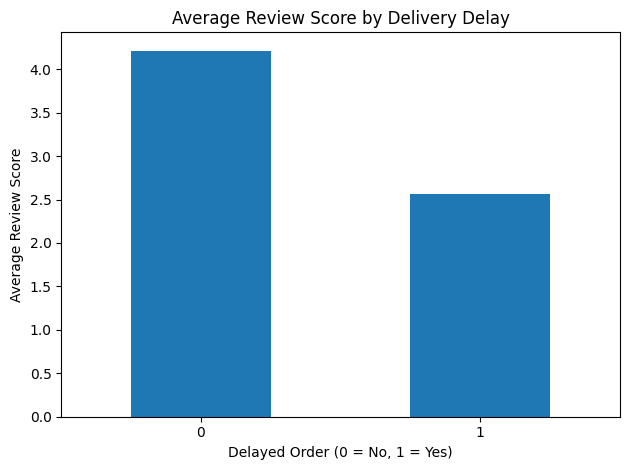

In [4]:
review_summary.plot(kind="bar")

plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delayed Order (0 = No, 1 = Yes)")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
state_revenue = (
    customers[["customer_id", "customer_state"]]
    .merge(
        orders[["order_id", "customer_id"]],
        on="customer_id"
    )
    .merge(
        order_items[["order_id", "revenue"]],
        on="order_id"
    )
    .groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: revenue, dtype: float64

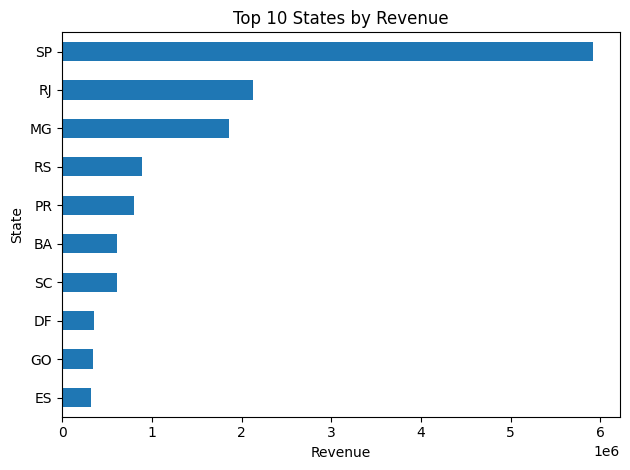

In [6]:
state_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [7]:
category_revenue = (
    order_items[["order_id", "product_id", "revenue"]]
    .merge(
        products[
            ["product_id", "product_category_name_english"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64

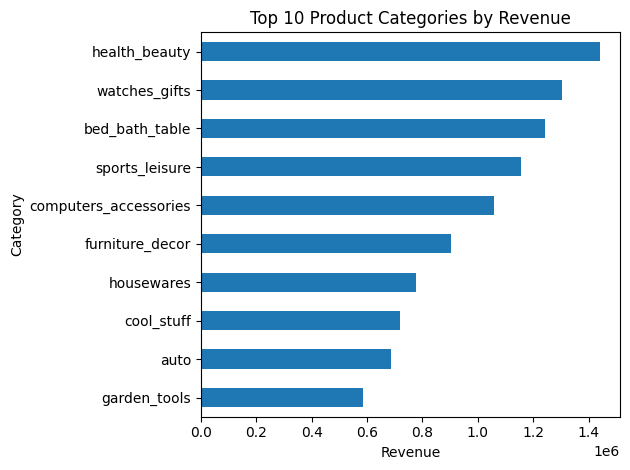

In [8]:
category_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

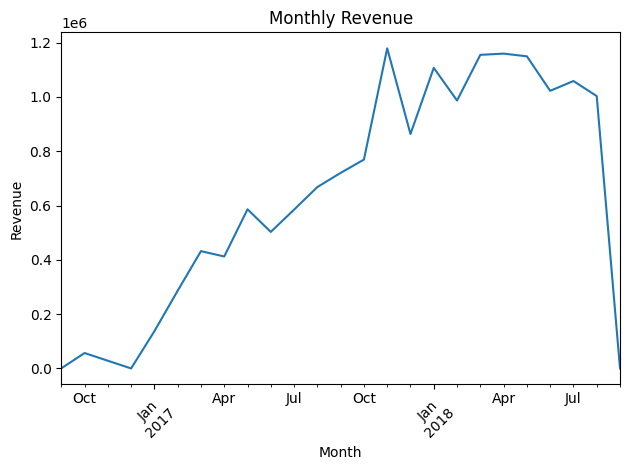

In [9]:
monthly_revenue = (
    order_items
    .merge(
        orders[["order_id", "month"]],
        on="order_id"
    )
    .groupby("month")["revenue"]
    .sum()
)

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()